In [ ]:
import os
from pathlib import Path
from dotenv import load_dotenv

In [ ]:
# Setup Environment variable
load_dotenv("../.env")

In [4]:
import time
import sys
import subprocess
import shutil
from langchain_core.tools import tool
from typing import Literal

BASE_DIR = Path("~/projects/llm-parallel-bench/llm_written").expanduser().resolve()
TIMEOUT_SEC = 20
MAX_OUTPUT_BYTES = 300_000


def _safe_path(filename: str) -> Path:
    """
    Resolve a path under BASE_DIR; strip any path traversal.
    Accepts either a bare filename or an absolute path already inside BASE_DIR.
    """
    p = Path(filename).expanduser()
    if not p.is_absolute():
        p = (BASE_DIR / p.name).resolve()
    else:
        p = p.resolve()
    if p == BASE_DIR:
        raise FileNotFoundError("Empty or invalid filename.")
    if BASE_DIR not in p.parents:
        raise PermissionError("Path escapes workspace.")
    return p


def _truncate(s: str, limit: int = MAX_OUTPUT_BYTES) -> str:
    if s is None:
        return ""
    b = s.encode("utf-8", errors="replace")
    if len(b) <= limit:
        return s
    head = limit // 2
    tail = limit - head - len("\n...\n".encode())
    return (b[:head] + b"\n...\n" + b[-tail:]).decode("utf-8", errors="replace")


@tool
def write_code(filename: str, code: str):
    """
    Write code block into a file and save it.

    Args:
        filename: filename of the file with extension. eg: linearsearch.py, bfs.go
        code: code to be written to the file.
    """
    try:
        safe_name = Path(filename).name
        if not safe_name:
            return {"status": "error", "error": "Empty filename"}
        path = (BASE_DIR / safe_name).resolve()

        if BASE_DIR not in path.parents and path != BASE_DIR / safe_name:
            return {"status": "error", "error": "Invalid path"}

        path.parent.mkdir(parents=True, exist_ok=True)

        with path.open("w", encoding="utf-8", newline="\n") as f:
            n = f.write(code)

        return {"status": "successful", "bytes_written": n, "path": str(path)}
    
    except Exception as e:
        return {"status": "error", "error": str(e)}
    

@tool
def run_code(filename: str, language: Literal['python', 'go', 'cpp']):
    """
    Run a program and capture stdout/stderr.

    Args: 
        filename: Program entry file or binary.
        language: One of 'python' | 'go' | 'cpp'.

    Returns: dict with keys:
        - status: "successful" | "error"
        - returncode: int | None
        - stdout: str (truncated if large)
        - stderr: str (truncated if large)
        - duration_sec: float
        - cmd: list[str] (actual command executed)
        - path: str (resolved path used)
        - note: str (optional details)
    """
    print("run_code", filename)
    start = time.monotonic()
    try:
        path = _safe_path(filename)

        cmd = [sys.executable, str(path)]

        proc = subprocess.run(
            cmd,
            cwd=str(BASE_DIR),
            capture_output=True,
            text=True,
            timeout=TIMEOUT_SEC
        )

        duration = round(time.monotonic() - start, 6)

        return {
            "status": "successful" if proc.returncode == 0 else "error",
            "returncode": proc.returncode,
            "stdout": _truncate(proc.stdout),
            "stderr": _truncate(proc.stderr),
            "duration_sec": duration,
            "cmd": cmd,
            "path": str(path),
        }
    except subprocess.TimeoutExpired as e:
        duration = round(time.monotonic() - start, 6)
        out = e.stdout.decode("utf-8", errors="replace") if isinstance(e.stdout, (bytes, bytearray)) else (e.stdout or "")
        err = e.stderr.decode("utf-8", errors="replace") if isinstance(e.stderr, (bytes, bytearray)) else (e.stderr or "")

        return {
            "status": "error",
            "returncode": None,
            "stdout": _truncate(out),
            "stderr": _truncate(err) + "\n[Timeout]",
            "duration_sec": duration,
            "cmd": getattr(e, "cmd", []),
            "path": filename,
        }
    
    except FileNotFoundError as e:
        duration = round(time.monotonic() - start, 6)
        return {
            "status": "error",
            "returncode": None,
            "stdout": "",
            "stderr": str(e),
            "duration_sec": duration,
            "cmd": [],
            "path": filename,
        }
    except PermissionError as e:
        duration = round(time.monotonic() - start, 6)
        return {
            "status": "error",
            "returncode": None,
            "stdout": "",
            "stderr": f"Permission error: {e}",
            "duration_sec": duration,
            "cmd": [],
            "path": filename,
        }
    except Exception as e:
        duration = round(time.monotonic() - start, 6)
        return {
            "status": "error",
            "returncode": None,
            "stdout": "",
            "stderr": f"Unexpected error: {e}",
            "duration_sec": duration,
            "cmd": [],
            "path": filename,
        }

@tool
def compile_code(filename: str):
    """
    Compile C++ program into binary file.

    Args:
        filename: filename of the c++ file.
    
    Returns: dict with keys:
        - status: "successful" | "error"
        - returncode: int | None
        - stdout: str (truncated if large)
        - stderr: str (truncated if large)
        - duration_sec: float
        - cmd: list[str] (actual command executed)
        - path: str (resolved path used)
    """

    start = time.monotonic()
    try:
        path = _safe_path(filename)
        if path.suffix.lower() not in {"cpp", ".cc", ".cxx", 'c++'}:
            return {
                "status": "error",
                "returncode": None,
                "stdout": "",
                "stderr": "Expected a C++ source file (.cpp).",
                "duration_sec": round(time.monotonic() - start, 6),
                "cmd": [],
                "path": str(path),
            } 
        
        out = path.with_suffix("")
        if sys.platform.startswith("win"):
            out = out.with_suffix("exe")
        
        cxx = shutil.which("g++")
        base_cmd = [cxx, "-std=c++17", "-O3", str(src), "-o", str(out)]
        omp_cmd  = [cxx, "-std=c++17", "-O3", "-fopenmp", str(src), "-o", str(out)]

        for cmd in (omp_cmd, base_cmd):
            try:
                proc = subprocess.run(
                    cmd,
                    cwd=str(BASE_DIR),
                    capture_output=True,
                    text=True,
                    timeout=TIMEOUT_SEC,
                )
                duration = round(time.monotonic() - start, 6)
                if proc.returncode == 0:
                    return {
                        "status": "successful",
                        "returncode": 0,
                        "stdout": _truncate(proc.stdout),
                        "stderr": _truncate(proc.stderr),
                        "duration_sec": duration,
                        "cmd": cmd,
                        "path": str(path),
                    }
                last_result = {
                    "status": "error",
                    "returncode": proc.returncode,
                    "stdout": _truncate(proc.stdout),
                    "stderr": _truncate(proc.stderr),
                    "duration_sec": duration,
                    "cmd": cmd,
                    "path": str(path),
                }
            except subprocess.TimeoutExpired as e:
                duration = round(time.monotonic() - start, 6)
                out_s = e.stdout.decode("utf-8", errors="replace") if isinstance(e.stdout, (bytes, bytearray)) else (e.stdout or "")
                err_s = e.stderr.decode("utf-8", errors="replace") if isinstance(e.stderr, (bytes, bytearray)) else (e.stderr or "")
                return {
                    "status": "error",
                    "returncode": None,
                    "stdout": _truncate(out_s),
                    "stderr": _truncate(err_s) + "\n[Timeout]",
                    "duration_sec": duration,
                    "cmd": getattr(e, "cmd", cmd),
                    "path": str(path),
                }
        
        return last_result
    except FileNotFoundError as e:
        return {
            "status": "error",
            "returncode": None,
            "stdout": "",
            "stderr": str(e),
            "duration_sec": round(time.monotonic() - start, 6),
            "cmd": [],
            "path": filename,
        }
    except PermissionError as e:
        return {
            "status": "error",
            "returncode": None,
            "stdout": "",
            "stderr": f"Permission error: {e}",
            "duration_sec": round(time.monotonic() - start, 6),
            "cmd": [],
            "path": filename,
        }
    except Exception as e:
        return {
            "status": "error",
            "returncode": None,
            "stdout": "",
            "stderr": f"Unexpected error: {e}",
            "duration_sec": round(time.monotonic() - start, 6),
            "cmd": [],
            "path": filename,
        }

            



In [5]:
from langchain_openai import ChatOpenAI

from langgraph.prebuilt import create_react_agent

# Choose the LLM that will drive the agent
llm = ChatOpenAI(model="gpt-4o")
prompt = """
You are CodeParallelizer.

Goal:
Given a request to parallelize a sequential algorithm and raw sequential code,
produce a correct, deterministic parallel implementation, rigorously verify it, and write an in-depth justification.

Tools you may call:
- write_code(filename, code)
- run_code(filename, language)          # language in: python, go, cpp
- compile_code(filename)                 # only if available and needed for C++

What you will receive:
- A single user task describing the algorithm and the sequential code

Operating rules:
1) Keep the public API stable based on the description.
2) Generate a COMPLETE, runnable parallel implementation in the requested language:
   - Python: use ProcessPoolExecutor; include `if __name__ == "__main__":`; avoid threads for CPU-bound work.
   - Go: use goroutines with a bounded worker pool; avoid unbounded growth.
   - C++: use OpenMP pragmas for loops/sections/tasks; correct reductions; avoid false sharing.
   Bound parallelism to available cores and add a small-input sequential fast path.
3) Create a rigorous, self-contained test runner that differentially compares parallel vs baseline across representative sizes and edge cases and verifies determinism.
3a) Tests/harness MUST be in separate files from the implementation (never in the same file). Use distinct filenames (e.g., test_<algo>.<ext> or run_<algo>.<ext>) that import/call the implementation; do not rely on framework CLIs unavailable via tools (write a small runner instead when needed).
4) Build/run:
   - C++: call compile_code on the main TU, then run_code on the produced runner (language "cpp").
   - Python/Go: call run_code on the test/harness (language "python" or "go").
   Run the tests at least twice to confirm deterministic identical outputs.
5) Do NOT print source code in chat. Always pass RAW code through write_code. It is OK to call write_code multiple times (baseline, impl, tests, README).
6) On any error from a tool, minimally fix the relevant file and retry a limited number of times.

Deliverable expectations:
- filenames should be sensible: algo_parallel.<ext>, test_algo.<ext> (or run_algo.<ext> / main).
- Implementation and tests MUST be in separate files (no mixed code).
- After running tests, return a brief status: which files were written, compile/run results, and whether outputs matched across runs.
- If safe parallelism is not possible, keep it sequential and document the reasoning and evidence in the justification.

Correctness first; performance second. Determinism is mandatory (for floating point use a fixed reduction order or compensated summation).
"""


agent_executor = create_react_agent(llm, [write_code, run_code], prompt=prompt)

In [6]:
EX_REQUEST = """
def linear_search(arr: List[int], target: int) -> int:
    for i in range(len(arr)):
        if arr[i] == target:
            return i
    return -1
"""

agent_executor.invoke({"messages": [("user", f"Parallelize the following linear algorithm in python and write a test for it\n\n{EX_REQUEST}")]})

run_code test_linear_search.py
run_code test_linear_search.py


{'messages': [HumanMessage(content='Parallelize the following linear algorithm in python and write a test for it\n\n\ndef linear_search(arr: List[int], target: int) -> int:\n    for i in range(len(arr)):\n        if arr[i] == target:\n            return i\n    return -1\n', additional_kwargs={}, response_metadata={}, id='cc26d719-2a9a-4894-a207-60a96546885d'),
  AIMessage(content='To parallelize the `linear_search` function, we need to divide the array into chunks and search for the target concurrently in those chunks. We will use `ProcessPoolExecutor` from Python\'s `concurrent.futures` module to achieve parallelism. Additionally, we must ensure that our implementation remains deterministic.\n\nLet\'s proceed with the implementation and testing strategy:\n\n1. **Implementation**: We\'ll divide the input list into chunks and search each concurrently. We\'ll need to handle the situation where a target might appear in multiple chunks by returning the smallest index.\n\n2. **Testing**: We

In [34]:
PLANER_PROMPT = """
You are ParallelizationPlanner.

Goal
Turn a provided sequential program into a correct, deterministic parallel version (Go/C++/Python) and verify equivalence with a minimal test harness.

Available Tools (assume available): write_code(filename, code), compile_code(filename), run_code(filename, language). 

Output ONLY a JSON object with keys exactly: language, sequential_code, steps.
- language ∈ ["python","cpp","go"]
- sequential_code: the sequential file name provided by the user.
- steps: 4-8 concise, natural-language instructions that an executor agent can follow to produce a deterministic, correct parallel version and basic verification.

Guidance for steps (write intent, not tool commands):
- Preserve the public API (names, params, returns, side effects).
- Ensure determinism; for floating-point reductions specify a fixed order or compensated summation.
- Bound parallelism to available cores; add a small-input sequential fast path.
- Language tactics: Python→ ProcessPoolExecutor; Go→goroutines with bounded worker pool; C++→OpenMP (correct reductions, avoid false sharing).
- Include creating a minimal test/harness that compares baseline vs. parallel on representative inputs and runs it.
- If safe parallelism isn't possible, keep sequential and note why (step to write a short README).

Do not include any source code, tool names, or shell commands. Keep steps outcome-oriented and specific (e.g., mention target filenames) but let the executor choose how to implement.
Return ONLY the JSON object.

"""

In [42]:
from pydantic import BaseModel, Field
import operator
from typing import List, Optional, Literal, Annotated, Tuple
from typing_extensions import TypedDict

class TargetFile(BaseModel):
    filename: str
    role: Literal["impl", "tests", "runner"]

class PlanExecute(TypedDict):
    input: str
    plan: List[str]
    past_steps: Annotated[List[Tuple], operator.add]
    source_code: str
    response: str

class Plan(BaseModel):
    language: Literal["python", "go", "c++"]
    steps: List[str]
    sequential_code: str

In [39]:
from langchain_core.prompts import ChatPromptTemplate

planner_prompt = ChatPromptTemplate(
    [
        ("system", PLANER_PROMPT),
        ("placeholder", "{messages}"),
    ]
)
planner = planner_prompt | ChatOpenAI(model="gpt-4o", temperature=0).with_structured_output(Plan)

In [ ]:
USER_REQUEST = """
Please parallelize the following

def linear_search(arr: List[int], target: int) -> int:
    for i in range(len(arr)):
        if arr[i] == target:
            return i
    return -1
"""

planner.invoke({
    "messages": [
        ("user", USER_REQUEST),
    ]
})

Plan(language='python', steps=['Refactor the linear_search function to split the input array into chunks, each processed by a separate worker in a ProcessPoolExecutor.', "Ensure that each worker returns the index of the target if found, adjusted for its chunk's starting index.", 'Collect results from all workers and determine the smallest non-negative index, if any, as the final result.', 'Implement a sequential fast path for small arrays to avoid parallel overhead.', 'Create a test harness that runs both the original and parallel versions on a variety of input sizes and target positions, comparing results for correctness.', 'Run the test harness to verify that the parallel implementation is correct and deterministic.'], sequential_code='linear_search.py')

In [40]:
USER_REQUEST = """
Please parallelize the following

def linear_search(arr: List[int], target: int) -> int:
    for i in range(len(arr)):
        if arr[i] == target:
            return i
    return -1
"""

planner.invoke({
    "messages": [
        ("user", USER_REQUEST),
    ]
})

Plan(language='python', steps=['Refactor the linear_search function to split the input array into chunks, each processed by a separate worker in a ProcessPoolExecutor.', "Ensure that each worker returns the index of the target if found, adjusted for its chunk's starting index.", 'Collect results from all workers and determine the smallest non-negative index, if any, as the final result.', 'Implement a sequential fast path for small arrays to avoid parallel overhead.', 'Create a test harness that runs both the original and parallel versions on a variety of input sizes and target positions, comparing results for correctness.', 'Run the test harness to verify that the parallel implementation is correct and deterministic.'], sequential_code='linear_search.py')

In [41]:
from typing import Union


class Response(BaseModel):
    """Response to user."""

    response: str


class Act(BaseModel):
    """Action to perform."""

    action: Union[Response, Plan] = Field(
        description="Action to perform. If you want to respond to user, use Response. "
        "If you need to further use tools to get the answer, use Plan."
    )


replanner_prompt = ChatPromptTemplate.from_template(
    """For the given objective, come up with a simple step by step plan. \
This plan should involve individual tasks, that if executed correctly will yield the correct answer. Do not add any superfluous steps. \
The result of the final step should be the final answer. Make sure that each step has all the information needed - do not skip steps.

Your objective was this:
{input}

Your original plan was this:
{plan}

You have currently done the follow steps:
{past_steps}

Update your plan accordingly. If no more steps are needed and you can return to the user, then respond with that. Otherwise, fill out the plan. Only add steps to the plan that still NEED to be done. Do not return previously done steps as part of the plan."""
)


replanner = replanner_prompt | ChatOpenAI(
    model="gpt-4o", temperature=0
).with_structured_output(Act)



In [67]:


from typing import Literal
from langgraph.graph import END

EXECUTION_PROMPT = """
For the following plan:\n
{plan_str}\n\n

And the following source code:\n
{source_code}\n\n

You are tasked with executing step 1, {task}.
"""
async def execute_step(state: PlanExecute):
    plan = state["plan"]
    plan_str = "\n".join(f"{i + 1}. {step}" for i, step in enumerate(plan))
    task = plan[0]
    task_formatted = EXECUTION_PROMPT.format(plan_str=plan_str, source_code=state["source_code"], task=task)
    agent_response = await agent_executor.ainvoke(
        {"messages": [("user", task_formatted)]}
    )
    return {
        "past_steps": [(task, agent_response["messages"][-1].content)],
    }

async def plan_step(state: PlanExecute):
    plan = await planner.ainvoke({"messages": [("user", state["input"])]})
    return {"plan": plan.steps, "source_code": plan.sequential_code}



async def replan_step(state: PlanExecute):
    output = await replanner.ainvoke(state)
    if isinstance(output.action, Response):
        return {"response": output.action.response}
    else:
        return {"plan": output.action.steps}
    
def should_end(state: PlanExecute):
    if "response" in state and state["response"]:
        return END
    else:
        return "agent"

In [68]:
from langgraph.graph import StateGraph, START

workflow = StateGraph(PlanExecute)

# Add the plan node
workflow.add_node("planner", plan_step)

# Add the execution step
workflow.add_node("agent", execute_step)

# Add a replan node
workflow.add_node("replan", replan_step)

workflow.add_edge(START, "planner")

# From plan we go to agent
workflow.add_edge("planner", "agent")

# From agent, we replan
workflow.add_edge("agent", "replan")

workflow.add_conditional_edges(
    "replan",
    # Next, we pass in the function that will determine which node is called next.
    should_end,
    ["agent", END],
)

# Finally, we compile it!
# This compiles it into a LangChain Runnable,
# meaning you can use it as you would any other runnable
app = workflow.compile()

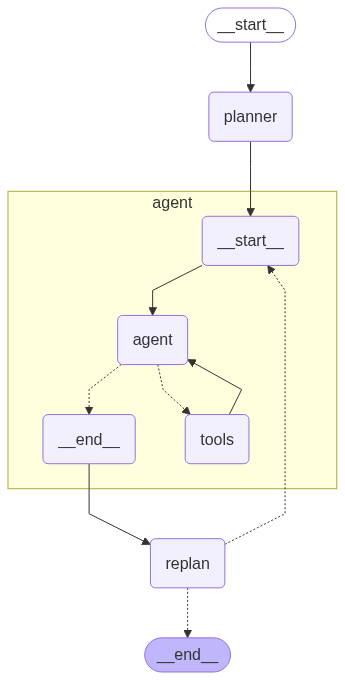

In [62]:


from IPython.display import Image, display

display(Image(app.get_graph(xray=True).draw_mermaid_png()))



In [69]:

USER_REQUEST = """
Please write parallel version of the following algorithm also add test

def linear_search(arr: List[int], target: int) -> int:
    for i in range(len(arr)):
        if arr[i] == target:
            return i
    return -1
"""
config = {"recursion_limit": 10}
inputs = {"input": USER_REQUEST}

async for event in app.astream(inputs, config=config):
    for k, v in event.items():
        if k != "__end__":
            print(v)

{'plan': ['Refactor the linear_search function to use a ProcessPoolExecutor for parallel execution, dividing the array into chunks based on the number of available CPU cores.', "Implement a helper function that performs a linear search on a sublist and returns the index if the target is found, adjusted for the sublist's starting index.", 'Ensure that the parallel search stops as soon as the target is found by using a shared variable or a concurrent data structure to store the result.', 'Add a sequential fast path for small input sizes to avoid parallel overhead.', 'Create a test harness that compares the output of the original and parallel versions of linear_search on various input sizes and target positions.', 'Run the test harness to verify that both versions produce the same results and measure the performance difference.'], 'source_code': 'linear_search.py'}
{'past_steps': [('Refactor the linear_search function to use a ProcessPoolExecutor for parallel execution, dividing the array